# An example of PyAge to calibrate LPM models on CFCs data

All files necessary for the code to work

In [1]:
%matplotlib inline

In [2]:
# Classcial imports of python
import copy
import functools
import numpy as np
import sys        
import os         
import math                                 

# Specific imports necessary for the code to run
import global_parameters as gp
import LPM.LPM_generate as LPM_generate
import calibration.workflows.synthetic_test
import concentrations.concentrations as co
from sites.ploemeur.postprocessing import appli_ploemeur_tools
import convolution.convolution_tracers as convolution_tracers                     
import concentrations.concentrations as concentrations        
from concentrations import concentrations_time as ct
import calibration.utils.systematic_sampling as calibration_exploration

## Display Options

Selection of the different types of outputs

In [3]:
# ---- DISPLAY OPTIONS + ROOT OUTPUT DIRECTORY ------------
# Output options
display = gp.display_options()
display.text = True
display.figure = True
display.figure_close = False
display.figure_save = True  

## Concentration data

Defined by the directory and file names. These should be modified to match the location of the data in hard-drive directories

<span style="color:red">*Directory should be entered here if needed; default is sites/ploemeur/data under ROOT_DIRECTORY*</span>

In [4]:
# ---------------- CONCENTRATIONS DATA ------------------
directory = os.path.join(gp.ROOT_DIRECTORY, "sites", "ploemeur", "data")     # Specific location of directory should be put here
file = "ploemeur_F09_2010"        # Specific file name
# file = "ploemeur_F22_2007"

In [6]:
# Data Loading
concentration_sampled=co.Concentrations(file_load=True, file_name=os.path.join(os.path.join(gp.ROOT_DIRECTORY, "sites", "ploemeur", "data"),file))
concentration_sampled.display(display)

FileNotFoundError: [Errno 2] File C:\DATA\codes-github-public\trac-2-age\python\sources\tests_data\ploemeur_F09_2010 does not exist: 'C:\\DATA\\codes-github-public\\trac-2-age\\python\\sources\\tests_data\\ploemeur_F09_2010'

## LPM model

Defined by te LPM type and the directory where the characteristics of the LPM are given
Parameters are acceptable boundaries, initial values for calibration and Metropolis Hastings parameters 

In [22]:
lpm_type = "dirac_double"
directory_lpm = os.path.join(gp.ROOT_DIRECTORY, "sites", "ploemeur", "data", "LPM_data")
directory_lpm = os.path.join(gp.ROOT_DIRECTORY, "sites", "ploemeur", "data", "LPM_data")
print("parameters for the calibration are in directory:\n\t", directory_lpm)

parameters for the calibration are in directory:
	 C:\DATA\codes-github-public\trac-2-age\python\\sources\tests_data\ploemeur\LPM_data


## Output Directory

In [21]:
# ---------------- OUTPUT DIRECTORY ----------------------
display.directory = gp.results_directory(gp.ROOT_DIRECTORY_RESULTS,"test_cases")
display.directory = gp.results_directory(display.directory,file)

## Reachable Concentrations

With a systematic sampling of the parameter space, displays the concentrations that can be reached with the chosen LPM

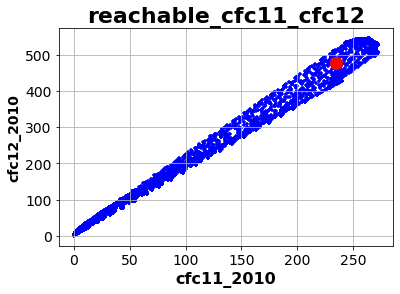

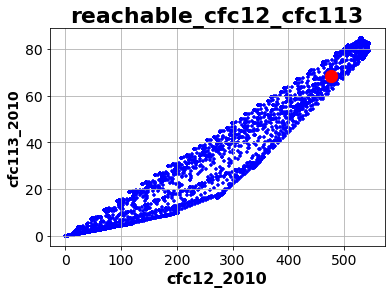

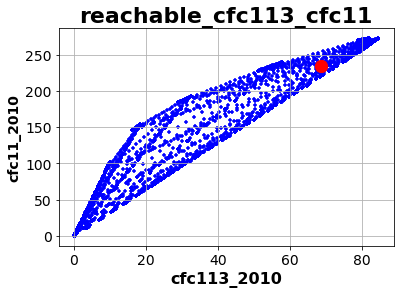

In [18]:
resolution=10000
# ---------------- REACHABLE CONCENTRATIONS -------------
directory_cr = gp.results_directory(display.directory,"reachable_concentrations")
display_cr=copy.deepcopy(display)
display_cr.directory_results=gp.results_directory(display.directory,"reachable_concentrations")
cr = calibration_exploration.SystematicSampling( lpm_type, concentration_sampled.names(), date = concentration_sampled.cv["date"], resolution=resolution,display_options=display_cr)
cr.compute_concentrations()
cr.output()
cr.display_concentrations_with_data(concentration_sampled)

## Calibration
### Parameters
Parameters for the Forward error propagation and Metropolis Hastings Methods 

In [9]:
# ---------------- CALIBRATION PARAMETERS ----------------
calparam=[None]*2
# ---------------- FORWARD UNCERTAINTY QUANTIFICATION -----------------------------
calparam[0] = calibration_lpm_tracer.CalibrationParameters("forward_uncertainty_quantification")  
calparam[0].fuq_n = 1*50
calparam[0].simplex_init_multiples_n = 1*10

# ---------------- METROPOLIS HASTINGS --------------------
# Method and Parameters  
calparam[1] = calibration_lpm_tracer.CalibrationParameters("Metropolis_Hastings")    
calparam[1].MH_n = 50000 #0
calparam[1].MH_monitor = True
calparam[1].MH_display_traj = True
calparam[1].MH_display_text = False
calparam[1].MH_likelihood = True
calparam[1].MH_prior = False
# calparam[1].MH_step.define_by_prop(0.005)
calparam[1].MH_step.define_by_value()

### Calibration per se

In [1]:
# ---------------- CALIBRATION -------------
lpm_calibration=[None]*2
lpm_resuls=[None]*2
for i in range(len(lpm_calibration)):
    # Outputs of Interpration 
    directory_calibration = gp.results_directory(display.directory,calparam[i].method)
    # Calibration
    lpm_calibration[i] = calibration_lpm_tracer.Calibration(concentration_sampled,lpm_type,calparam[i],directory_results=directory_calibration,directory_lpm=directory_lpm)
    lpm_results[i]=lpm_calibration[i].compute_concentrations()
    # Stores/Writes Results
    lpm_calibration[i].write_calibrated_lpm(lpm_results)


NameError: name 'gp' is not defined

### Displays Results as graphics 
Distribution of parameters 
Distribution of concentrations
Relations between parameters (when number of parameters is larger than 2) 

In [1]:
# ---------------- SYNTHETIC FIGURES --------------------
lpm_results[0].display_parameters_dist(self_method=lpm_calibration[0].method,lpm_reference=None,lpm_2nd=lpm_results[1],lpm_2nd_method=lpm_calibration[1].method,directory=display.directory,display_text=True)

NameError: name 'lpm_results' is not defined

### Objective function representation
Crosscuts when parameter number is larger than 3 

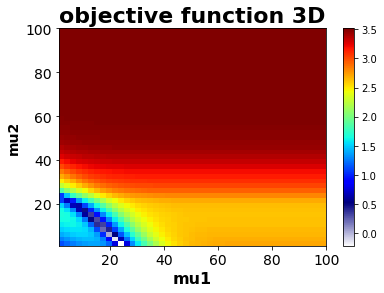

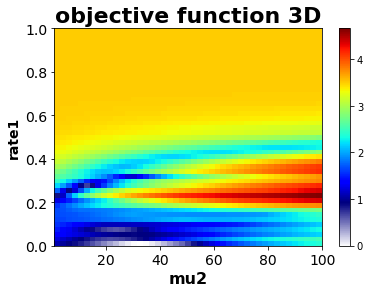

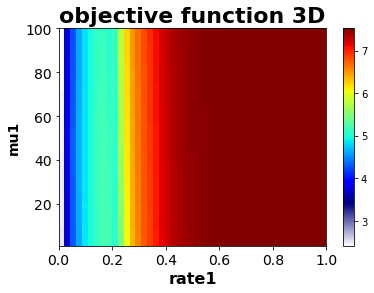

In [12]:
# ------- OBJECTIVE FUNCTION -------------------------------
lpm_calibration[1].build_objective_function(display,resolution=resolution)

### Resulting concentration chronicles of tracers and models 
Models are represented by lines of different colors

C:\DATA\results\PyAge\test_cases\ploemeur_F09_2010 	 Metropolis_Hastings
C:\DATA\results\PyAge\test_cases\ploemeur_F09_2010 	 forward_uncertainty_quantification


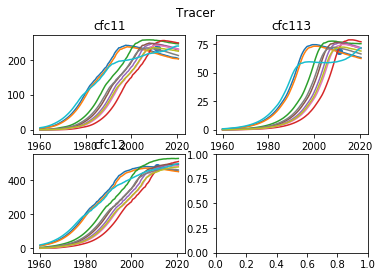

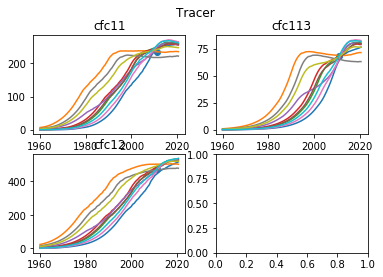

In [13]:
# ------------- CONCENTRATION OUTPUTS ----------------------
lpm=LPM_generate.LPM_generate(lpm_type,directory_lpm=gp.directory_lpm_data)
ct.display_concentration_times([display.directory],lpm,display)

All results (figures and data) are avialable in the following directory

In [14]:
print(display.directory)

C:\DATA\results\PyAge\test_cases\ploemeur_F09_2010
